Project Title : Estimating Fire Radiative Power (FRP) in Forest Fires Using Satellite Data

Problem Statement : Forest fires cause severe ecological and economic damage worldwide. Predicting Fire Radiative Power(FRP) is essential to assess fire intensity, spread, and emissions

Description : FRP is a key indicator of fire intensity and emissions, making it vital for monitoring wildfire severity. By using remote sensing data such as brightness, temperature, and location . This project applies Linear Regression to provide quick FRP estimates. The model enables faster decision-making for disaster management, emission assessment, and ecological protection.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix
import joblib
from google.colab import files


In [2]:
from google.colab import files
import pandas as pd

# Upload the file manually
uploaded = files.upload()


Saving 2000-2021 SINGLE TURKEY FIRE_M-C61_214067.csv to 2000-2021 SINGLE TURKEY FIRE_M-C61_214067.csv


In [18]:
# Load Dataset
df = pd.read_csv("/content/2000-2021 SINGLE TURKEY FIRE_M-C61_214067.csv")

print(df.head())

   latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0   36.8527    35.3594       306.0   2.1    1.4  2000-11-01       815   
1   40.5441    35.1786       307.8   1.1    1.0  2000-11-02       857   
2   40.1473    35.0444       305.3   1.1    1.0  2000-11-02       857   
3   40.5421    35.1909       310.0   1.1    1.0  2000-11-02       857   
4   41.2569    31.4172       307.9   1.1    1.0  2000-11-02       857   

  satellite instrument  confidence version  bright_t31   frp daynight  type  
0     Terra      MODIS          60    6.03       294.4  13.2        D   0.0  
1     Terra      MODIS          66    6.03       296.0   5.8        D   0.0  
2     Terra      MODIS          46    6.03       293.5   4.3        D   0.0  
3     Terra      MODIS          69    6.03       296.1   7.3        D   0.0  
4     Terra      MODIS           0    6.03       290.4   8.0        D   2.0  


/tmp/ipython-input-3482207096.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/2000-2021 SINGLE TURKEY FIRE_M-C61_214067.csv")


In [4]:
# Basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211309 entries, 0 to 211308
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   latitude    211309 non-null  float64
 1   longitude   211309 non-null  float64
 2   brightness  211309 non-null  float64
 3   scan        211309 non-null  float64
 4   track       211309 non-null  float64
 5   acq_date    211309 non-null  object 
 6   acq_time    211309 non-null  int64  
 7   satellite   211309 non-null  object 
 8   instrument  211309 non-null  object 
 9   confidence  211309 non-null  int64  
 10  version     211309 non-null  object 
 11  bright_t31  211309 non-null  float64
 12  frp         211309 non-null  float64
 13  daynight    211309 non-null  object 
 14  type        205918 non-null  float64
dtypes: float64(8), int64(2), object(5)
memory usage: 24.2+ MB
None


In [5]:
# clos
df.columns

Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight', 'type'],
      dtype='object')

In [6]:
# Basic Statistics & Missing Values
print(df.describe())
print("\nMissing Values:\n", df.isnull().sum())

            latitude      longitude     brightness           scan  \
count  211309.000000  211309.000000  211309.000000  211309.000000   
mean       38.096869      35.810523     323.103487       1.519333   
std         1.259144       4.218867      15.710290       0.735847   
min        35.822100      25.723600     300.000000       1.000000   
25%        37.113200      33.037500     311.300000       1.000000   
50%        37.711700      35.817400     322.100000       1.200000   
75%        38.931600      39.755500     331.300000       1.700000   
max        42.033000      44.796700     503.530000       4.820000   

               track       acq_time     confidence     bright_t31  \
count  211309.000000  211309.000000  211309.000000  211309.000000   
mean        1.183241    1127.559252      66.453923     302.475387   
std         0.228731     426.703297      19.297827      10.168149   
min         1.000000       0.000000       0.000000     265.200000   
25%         1.000000     845.0000

In [7]:
# Data Preprocessing
df['acq_date'] = pd.to_datetime(df['acq_date'], errors='coerce')
df['year'] = df['acq_date'].dt.year
df['month'] = df['acq_date'].dt.month

# Encode categorical (Day=1, Night=0)
df['daynight'] = df['daynight'].map({'D':1, 'N':0})

# Drop missing rows
df = df.dropna()

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 205918 entries, 0 to 205917
Data columns (total 17 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   latitude    205918 non-null  float64       
 1   longitude   205918 non-null  float64       
 2   brightness  205918 non-null  float64       
 3   scan        205918 non-null  float64       
 4   track       205918 non-null  float64       
 5   acq_date    205918 non-null  datetime64[ns]
 6   acq_time    205918 non-null  int64         
 7   satellite   205918 non-null  object        
 8   instrument  205918 non-null  object        
 9   confidence  205918 non-null  int64         
 10  version     205918 non-null  object        
 11  bright_t31  205918 non-null  float64       
 12  frp         205918 non-null  float64       
 13  daynight    205918 non-null  int64         
 14  type        205918 non-null  float64       
 15  year        205918 non-null  int32         
 16  month  

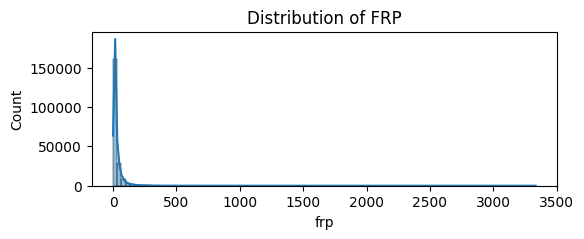

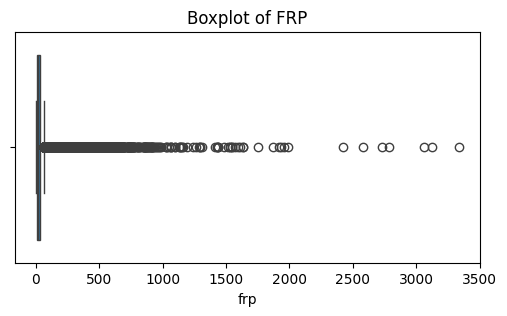

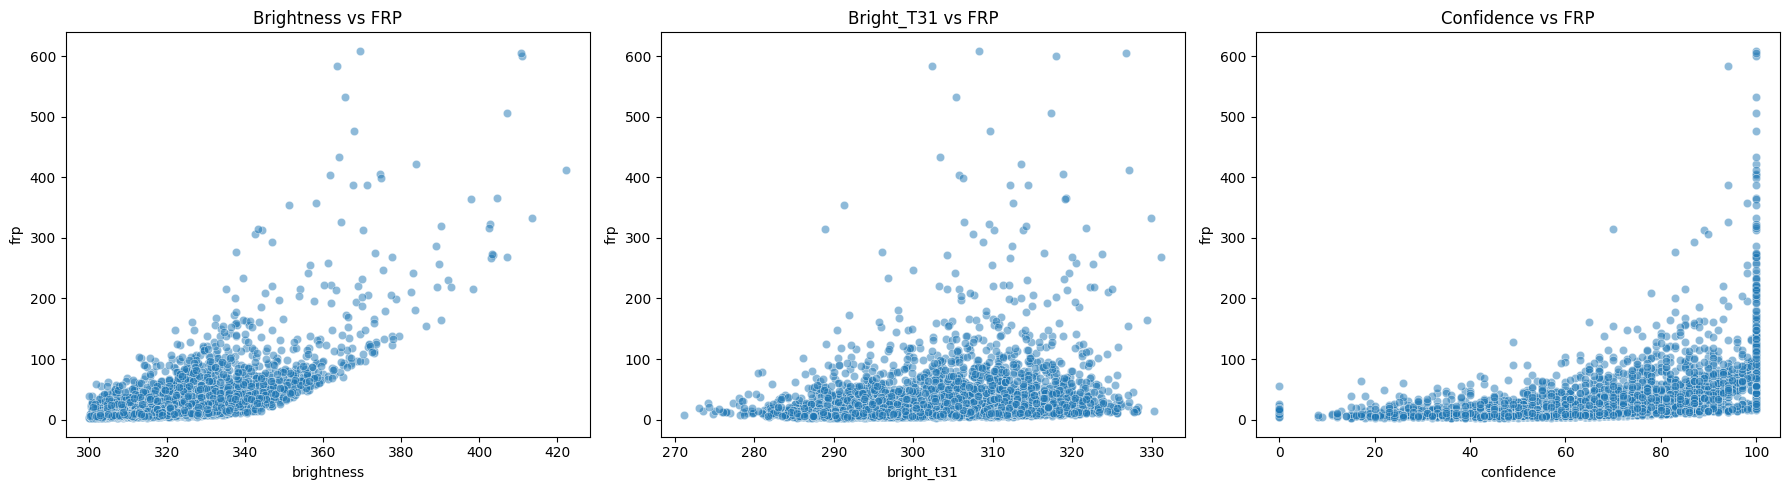

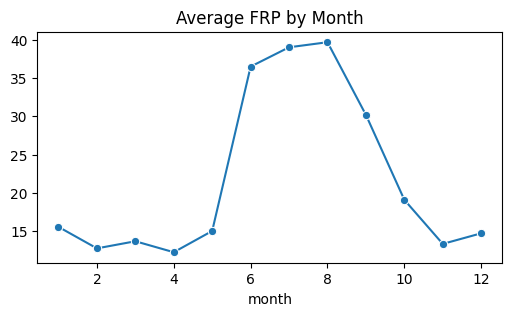

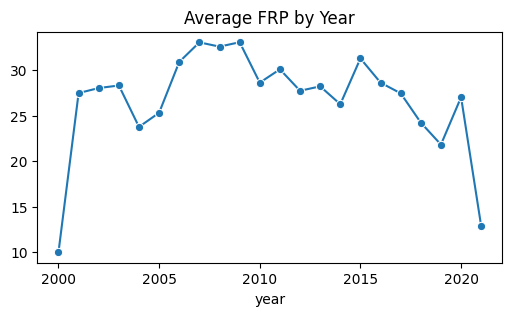

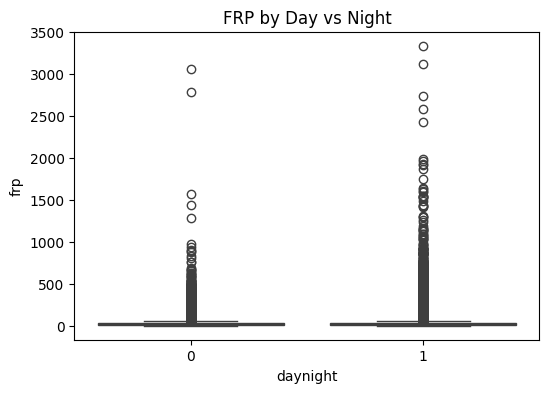

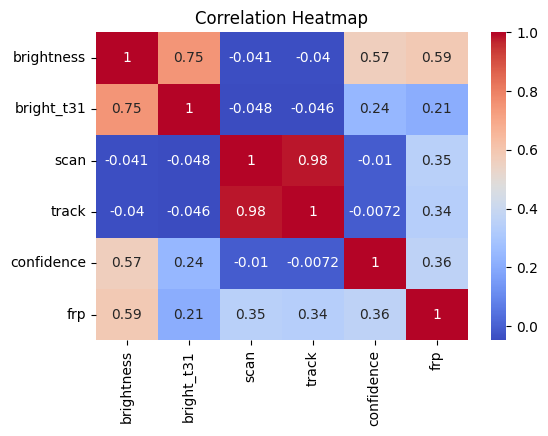

In [8]:
# Exploratory Data Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of FRP
plt.figure(figsize=(6,2))
sns.histplot(df['frp'], bins=100, kde=True)
plt.title("Distribution of FRP")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df['frp'])
plt.title("Boxplot of FRP")
plt.show()

# Scatterplots
sample_df = df.sample(5000, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.scatterplot(x='brightness', y='frp', data=sample_df, alpha=0.5, ax=axes[0])
axes[0].set_title("Brightness vs FRP")
sns.scatterplot(x='bright_t31', y='frp', data=sample_df, alpha=0.5, ax=axes[1])
axes[1].set_title("Bright_T31 vs FRP")
sns.scatterplot(x='confidence', y='frp', data=sample_df, alpha=0.5, ax=axes[2])
axes[2].set_title("Confidence vs FRP")
plt.tight_layout()
plt.show()

# Monthly & Yearly FRP trends
plt.figure(figsize=(6,3))
monthly_frp = df.groupby('month')['frp'].mean()
sns.lineplot(x=monthly_frp.index, y=monthly_frp.values, marker="o")
plt.title("Average FRP by Month")
plt.show()

plt.figure(figsize=(6,3))
yearly_frp = df.groupby('year')['frp'].mean()
sns.lineplot(x=yearly_frp.index, y=yearly_frp.values, marker="o")
plt.title("Average FRP by Year")
plt.show()

# Day vs Night FRP
plt.figure(figsize=(6,4))
sns.boxplot(x='daynight', y='frp', data=df)
plt.title("FRP by Day vs Night")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['brightness','bright_t31','scan','track','confidence','frp']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Feature Selection
features = ['brightness','bright_t31','confidence','scan','track','month','year','daynight']
X = df[features]
y = df['frp']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Regression Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

--- Regression Model Performance ---
Mean Absolute Error (MAE): 14.45
Root Mean Squared Error (RMSE): 28.44
R-squared (R²): 0.66


In [11]:
# Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X, y, cv=kfold, scoring='r2')

print("\n--- Cross-Validation Results ---")
print("R² scores across folds:", cv_scores)
print("Average R²:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))


--- Cross-Validation Results ---
R² scores across folds: [0.65750708 0.6161037  0.59823655 0.62096009 0.56397728]
Average R²: 0.6113569407384667
Standard Deviation: 0.030533799389756526


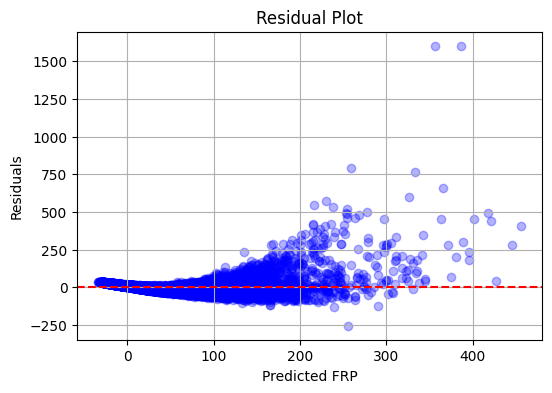

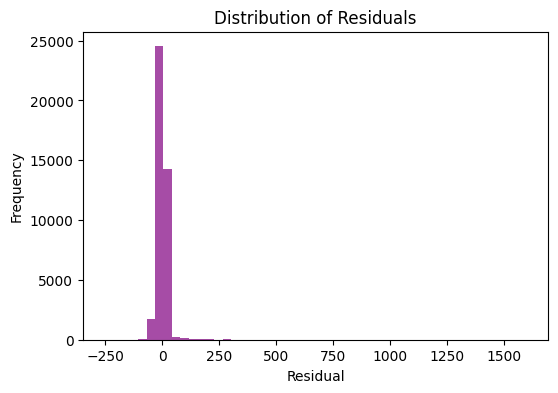

In [12]:
# Residual Analysis
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.3, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted FRP")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50, color="purple", alpha=0.7)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

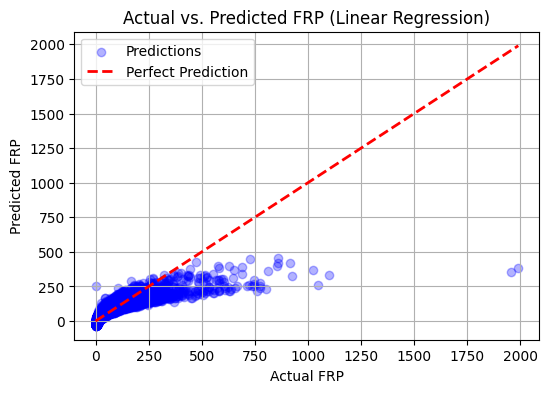

In [13]:
# Actual vs Predicted Plot
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.3, color="blue", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         '--r', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")
plt.title("Actual vs. Predicted FRP (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Classification: FRP Intensity Levels
bins = [0, 15, 50, df['frp'].max()]
labels = ['Low', 'Medium', 'High']
df['frp_class'] = pd.cut(df['frp'], bins=bins, labels=labels, right=False)

df_class = df.dropna(subset=['frp_class'])
print("Class Distribution:\n", df_class['frp_class'].value_counts())

X_class = df_class[features]
y_class = df_class['frp_class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train_c, y_train_c)
y_pred_c = classifier.predict(X_test_c)

Class Distribution:
 frp_class
Low       101909
Medium     77612
High       26396
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


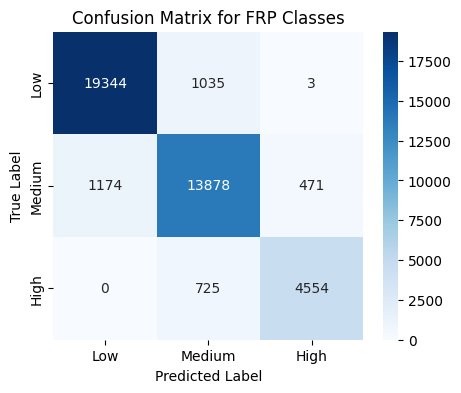

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c, labels=labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for FRP Classes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [16]:
# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test_c, y_pred_c))


--- Classification Report ---
              precision    recall  f1-score   support

        High       0.91      0.86      0.88      5279
         Low       0.94      0.95      0.95     20382
      Medium       0.89      0.89      0.89     15523

    accuracy                           0.92     41184
   macro avg       0.91      0.90      0.91     41184
weighted avg       0.92      0.92      0.92     41184



In [17]:
# Save regression model
joblib.dump(lr_model, "frp_linear_regression.pkl")

# Save classifier model (optional, if you want to use classification in deployment)
joblib.dump(classifier, "frp_classifier.pkl")


['frp_classifier.pkl']